# Stock Price — Time Series Analysis

## Objective

The objective of this project is to perform Time Series Analysis on historical stock price data to understand price movements, trends, and patterns over time.

## Dataset

The Stock Price dataset contains historical stock market data used to analyze changes in stock prices over time.

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook

## Workflow

1. Load and inspect the stock price dataset
2. Convert the date column into a suitable date-time format
3. Sort the data chronologically
4. Examine historical stock price trends
5. Analyze changes in stock prices over time
6. Create time series visualizations
7. Identify trends and patterns in the stock price data
8. Summarize the key findings

## Conclusion

Time Series Analysis was performed on historical stock price data to understand price movements and trends over time. The visualizations and analysis provided insights into the behavior and changes in stock prices throughout the observed period.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 2) Stock Prices Data Set.csv to 2) Stock Prices Data Set.csv


In [ ]:
df = pd.read_csv("2) Stock Prices Data Set.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (497472, 7)


In [ ]:
print(df.head())

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


In [ ]:
print(df.dtypes)

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object


In [ ]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

symbol            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object


In [ ]:
aapl = df[df["symbol"] == "AAPL"].copy()

print("AAPL data loaded!")
print("Number of rows:", len(aapl))

AAPL data loaded!
Number of rows: 1007


In [ ]:
aapl = aapl.sort_values("date")

print(aapl[["date", "close"]].head())

           date    close
1    2014-01-02  79.0185
484  2014-01-03  77.2828
967  2014-01-06  77.7042
1450 2014-01-07  77.1481
1933 2014-01-08  77.6371


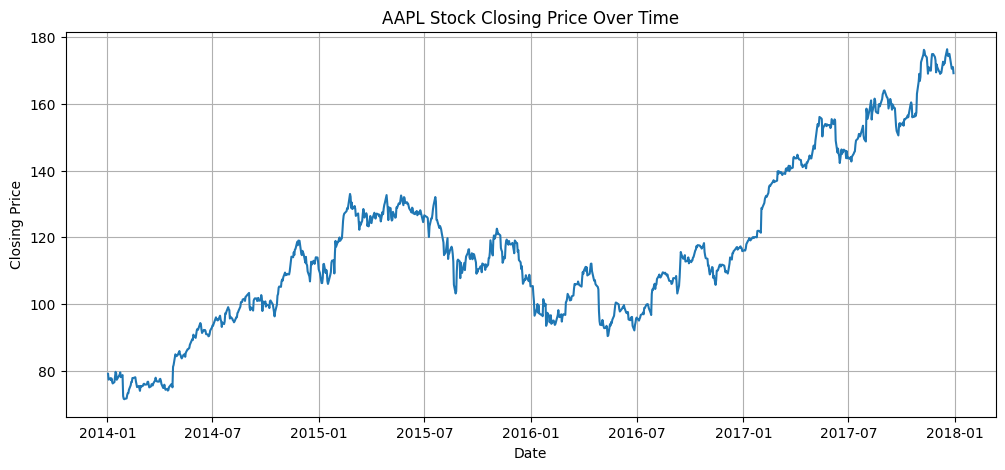

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(aapl["date"], aapl["close"])

plt.title("AAPL Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

In [ ]:
highest = aapl["close"].max()
lowest = aapl["close"].min()

print("Highest closing price:", highest)
print("Lowest closing price:", lowest)

Highest closing price: 176.42
Lowest closing price: 71.3974


In [ ]:
highest_row = aapl.loc[aapl["close"].idxmax()]
lowest_row = aapl.loc[aapl["close"].idxmin()]

print("Highest closing price:")
print(highest_row[["date", "close"]])

print("\nLowest closing price:")
print(lowest_row[["date", "close"]])

Highest closing price:
date     2017-12-18 00:00:00
close                 176.42
Name: 492928, dtype: object

Lowest closing price:
date     2014-01-30 00:00:00
close                71.3974
Name: 9178, dtype: object


In [ ]:
average_close = aapl["close"].mean()

print("Average closing price:", average_close)

Average closing price: 116.8398924528302


In [ ]:
print("First date:", aapl["date"].min())
print("Last date:", aapl["date"].max())

First date: 2014-01-02 00:00:00
Last date: 2017-12-29 00:00:00


In [ ]:
aapl["daily_change"] = aapl["close"].diff()

print(aapl[["date", "close", "daily_change"]].head())

           date    close  daily_change
1    2014-01-02  79.0185           NaN
484  2014-01-03  77.2828       -1.7357
967  2014-01-06  77.7042        0.4214
1450 2014-01-07  77.1481       -0.5561
1933 2014-01-08  77.6371        0.4890


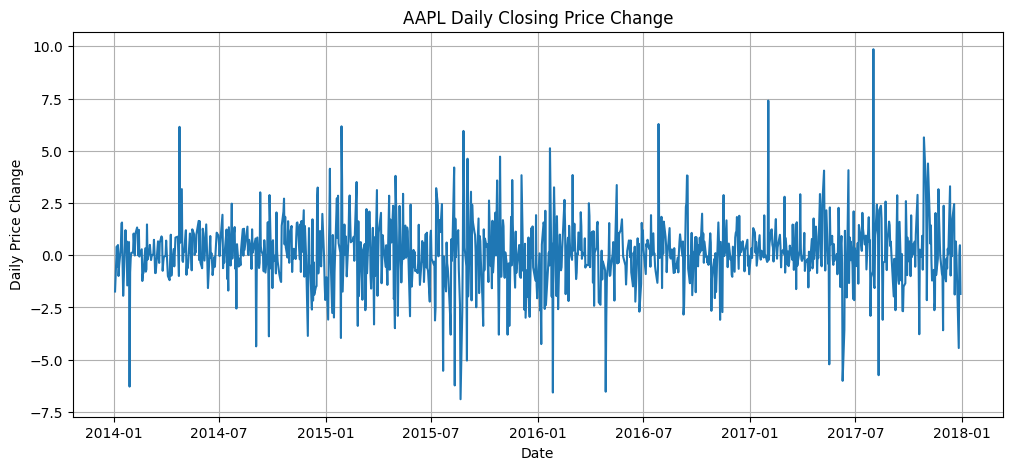

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(aapl["date"], aapl["daily_change"])

plt.title("AAPL Daily Closing Price Change")
plt.xlabel("Date")
plt.ylabel("Daily Price Change")

plt.grid(True)
plt.show()

In [ ]:
average_daily_change = aapl["daily_change"].mean()

print("Average daily price change:", average_daily_change)

Average daily price change: 0.0896734592445328


In [ ]:
aapl["daily_return"] = aapl["close"].pct_change() * 100

print(aapl[["date", "close", "daily_return"]].head())

           date    close  daily_return
1    2014-01-02  79.0185           NaN
484  2014-01-03  77.2828     -2.196574
967  2014-01-06  77.7042      0.545270
1450 2014-01-07  77.1481     -0.715663
1933 2014-01-08  77.6371      0.633846


In [ ]:
average_return = aapl["daily_return"].mean()

print("Average daily return:", average_return, "%")

Average daily return: 0.08595590429747017 %


In [ ]:
best_day = aapl.loc[aapl["daily_return"].idxmax()]
worst_day = aapl.loc[aapl["daily_return"].idxmin()]

print("Best trading day:")
print(best_day[["date", "daily_return"]])

print("\nWorst trading day:")
print(worst_day[["date", "daily_return"]])

Best trading day:
date            2014-04-24 00:00:00
daily_return                8.19818
Name: 37215, dtype: object

Worst trading day:
date            2014-01-28 00:00:00
daily_return              -7.992722
Name: 8212, dtype: object


In [ ]:
print(aapl.isnull().sum())

symbol          0
date            0
open            0
high            0
low             0
close           0
volume          0
daily_change    1
daily_return    1
dtype: int64


In [ ]:
aapl_clean = aapl.dropna(subset=["daily_change", "daily_return"]).copy()

print("Rows after cleaning:", len(aapl_clean))
print("Missing values:")
print(aapl_clean[["daily_change", "daily_return"]].isnull().sum())

Rows after cleaning: 1006
Missing values:
daily_change    0
daily_return    0
dtype: int64


In [ ]:
average_volume = aapl_clean["volume"].mean()

print("Average daily trading volume:", average_volume)

Average daily trading volume: 45156030.03180914


In [ ]:
highest_volume = aapl_clean.loc[aapl_clean["volume"].idxmax()]

print("Highest trading volume:")
print(highest_volume[["date", "volume", "close"]])

Highest trading volume:
date      2014-01-28 00:00:00
volume              266833581
close                 72.3571
Name: 8212, dtype: object


In [ ]:
lowest_volume = aapl_clean.loc[aapl_clean["volume"].idxmin()]

print("Lowest trading volume:")
print(lowest_volume[["date", "volume", "close"]])

Lowest trading volume:
date      2016-11-25 00:00:00
volume               11475922
close                  111.79
Name: 358971, dtype: object


In [ ]:
first_close = aapl["close"].iloc[0]
last_close = aapl["close"].iloc[-1]

total_change = last_close - first_close
total_return = (total_change / first_close) * 100

print("First closing price:", first_close)
print("Last closing price:", last_close)
print("Total price change:", total_change)
print("Total return:", total_return, "%")

First closing price: 79.0185
Last closing price: 169.23
Total price change: 90.21149999999999
Total return: 114.16503730139142 %


In [ ]:
aapl_clean.to_csv("AAPL_Time_Series_Analysis.csv", index=False)

print("Cleaned AAPL dataset saved successfully!")

Cleaned AAPL dataset saved successfully!
